In [52]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [53]:
df = pd.read_csv("./data/IMDB Dataset.csv")

In [54]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [55]:
df.sample(5)

,review,sentiment
49985,Imaginary Heroes is clearly the best film of t...,positive
39364,When I was 13 or so I was lucky enough to find...,negative
12104,"From the beginning of this film,with it's ""The...",negative
20725,"This movie (and yes, it's a movie - it was sho...",positive
13754,Some may think Imaginary Heroes is a movie exa...,positive


In [56]:
df_pos = df[df['sentiment']=='positive'][:5000]
df_neg = df[df['sentiment']=='negative'][:5000]

df_reviews = pd.concat([df_pos, df_neg ])

In [57]:
from sklearn.model_selection import train_test_split


In [58]:
train,test = train_test_split(df_reviews,test_size =0.33,random_state=42)

In [59]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [60]:
train_y.value_counts()

sentiment
negative    3378
positive    3322
Name: count, dtype: int64

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [62]:
tfidf = TfidfVectorizer(stop_words='english')
train_x_vector = tfidf.fit_transform(train_x)
test_x_vector = tfidf.transform(test_x)

In [63]:
train_x.shape

(6700,)

In [64]:
train_x_vector.shape

(6700, 44107)

In [65]:
type(train_x_vector)

scipy.sparse._csr.csr_matrix

In [66]:
primera_resenia = pd.DataFrame.sparse.from_spmatrix(train_x_vector,
                                  index=train_x.index,
                                  columns=tfidf.get_feature_names_out()).iloc[0]

In [67]:
primera_resenia

00           NaN
000          NaN
007          NaN
00am         NaN
00s          NaN
            ... 
ísnt         NaN
île          NaN
önsjön       NaN
über         NaN
überwoman    NaN
Name: 6746, Length: 44107, dtype: Sparse[float64, nan]

In [68]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [69]:
primera_resenia[primera_resenia != 0]

00           NaN
000          NaN
007          NaN
00am         NaN
00s          NaN
            ... 
ísnt         NaN
île          NaN
önsjön       NaN
über         NaN
überwoman    NaN
Name: 6746, Length: 44107, dtype: Sparse[float64, nan]

In [70]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [71]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(train_x_vector, train_y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [72]:
print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all I gave this movie away'])))

['positive']
['positive']
['negative']


In [73]:
print(svc.score(test_x_vector, test_y))

0.8706060606060606


In [74]:
from sklearn.metrics import f1_score

f1_score(test_y,svc.predict(test_x_vector),
          labels = ['positive','negative'],average=None)

array([0.87400413, 0.86701962])

In [75]:
from sklearn.metrics import classification_report

print(classification_report(test_y,
                            svc.predict(test_x_vector),
                            labels = ['positive','negative']))

              precision    recall  f1-score   support

    positive       0.87      0.88      0.87      1678
    negative       0.88      0.86      0.87      1622

    accuracy                           0.87      3300
   macro avg       0.87      0.87      0.87      3300
weighted avg       0.87      0.87      0.87      3300



In [76]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(test_y,
                           svc.predict(test_x_vector),
                           labels = ['positive', 'negative'])
conf_mat

array([[1481,  197],
       [ 230, 1392]])

In [77]:
###

In [78]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(train_x_vector, train_y)

lr_pred = lr.predict(test_x_vector)

print("Accuracy Logistic Regression:")
print(lr.score(test_x_vector, test_y))

print(classification_report(test_y, lr_pred))

Accuracy Logistic Regression:
0.8718181818181818
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87      1622
    positive       0.87      0.88      0.87      1678

    accuracy                           0.87      3300
   macro avg       0.87      0.87      0.87      3300
weighted avg       0.87      0.87      0.87      3300



In [79]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(train_x_vector, train_y)

dt_pred = dt.predict(test_x_vector)

print("Accuracy Decision Tree:")
print(dt.score(test_x_vector, test_y))

print(classification_report(test_y, dt_pred))

Accuracy Decision Tree:
0.7163636363636363
              precision    recall  f1-score   support

    negative       0.71      0.72      0.71      1622
    positive       0.73      0.71      0.72      1678

    accuracy                           0.72      3300
   macro avg       0.72      0.72      0.72      3300
weighted avg       0.72      0.72      0.72      3300



In [80]:
from sklearn.naive_bayes import GaussianNB

train_x_dense = train_x_vector.toarray()
test_x_dense = test_x_vector.toarray()

gnb = GaussianNB()

gnb.fit(train_x_dense, train_y)

gnb_pred = gnb.predict(test_x_dense)

print("Accuracy GaussianNB:")
print(gnb.score(test_x_dense, test_y))

print(classification_report(test_y, gnb_pred))

Accuracy GaussianNB:
0.6427272727272727
              precision    recall  f1-score   support

    negative       0.63      0.67      0.65      1622
    positive       0.66      0.62      0.64      1678

    accuracy                           0.64      3300
   macro avg       0.64      0.64      0.64      3300
weighted avg       0.64      0.64      0.64      3300



In [81]:
modelos = ['SVM', 'Logistic Regression', 'Decision Tree', 'GaussianNB']

accuracies = [
    svc.score(test_x_vector, test_y),
    lr.score(test_x_vector, test_y),
    dt.score(test_x_vector, test_y),
    gnb.score(test_x_dense, test_y)
]

comparacion = pd.DataFrame({
    'Modelo': modelos,
    'Accuracy': accuracies
})

comparacion

,Modelo,Accuracy
0,SVM,0.870606
1,Logistic Regression,0.871818
2,Decision Tree,0.716364
3,GaussianNB,0.642727


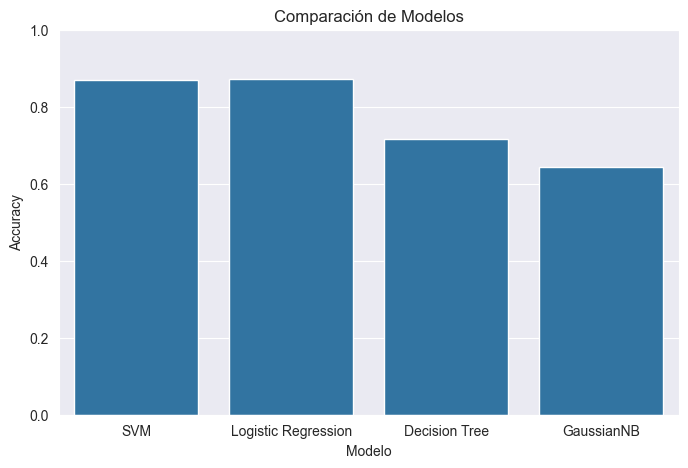

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Modelo',
    y='Accuracy',
    data=comparacion
)

plt.title('Comparación de Modelos')
plt.ylim(0,1)

plt.show()